In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os

print(os.listdir('/kaggle/input/datasets/mirichoi0218/insurance'))

['insurance.csv']


In [7]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
import glob
import pandas as pd

file_path = glob.glob('/kaggle/input/datasets/mirichoi0218/insurance/*.csv')[0]

print("File:", file_path)

df = pd.read_csv(file_path)

df.head()

File: /kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# View the column names
print("\nColumns:")
print(df.columns)

# Get information about the data
print("\nDataset information:")
df.info()

Dataset shape: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# Basic statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


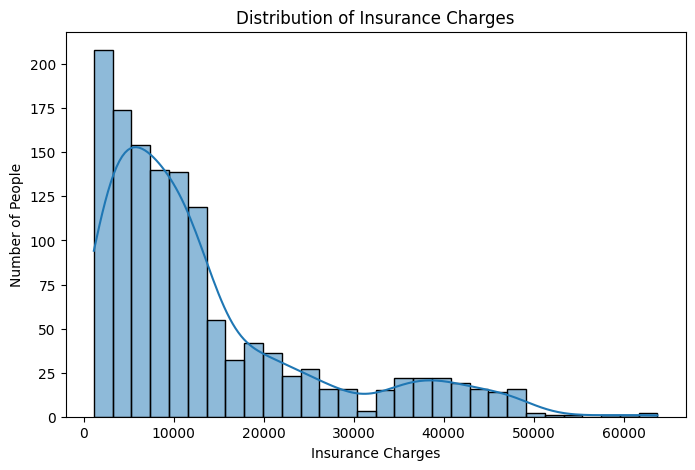

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of insurance charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Insurance Charges')
plt.ylabel('Number of People')
plt.show()

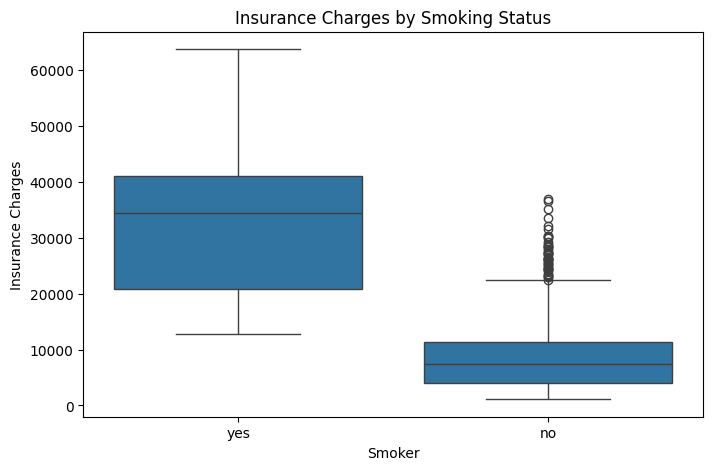

In [13]:
# Insurance charges by smoking status
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Insurance Charges')
plt.show()

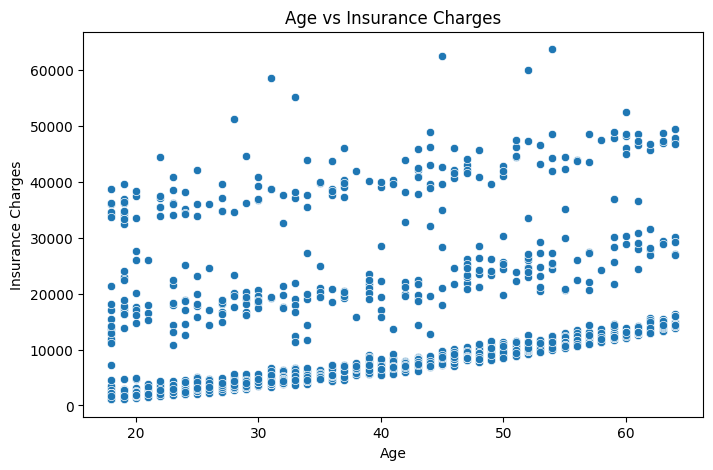

In [14]:
# Age vs insurance charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.show()

In [15]:
# Make a copy so we keep the original dataset
data = df.copy()

# Convert categorical variables into numbers
data = pd.get_dummies(
    data,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

# View the new dataset
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [16]:
print(data.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [17]:
X = data.drop('charges', axis=1)
y = data['charges']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Target (y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1070, 8)
Testing data: (268, 8)


In [19]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
-------------------------
MAE: 4181.19447375365
MSE: 33596915.85136145
RMSE: 5796.284659276273
R² Score: 0.7835929767120724


In [21]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE: 2550.0784706115096
MSE: 20942520.922619622
RMSE: 4576.299916157115
R² Score: 0.8651034329144947


In [23]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R² Score': [r2, r2_rf]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Random Forest,2550.078471,4576.299916,0.865103


In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [25]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("------------------------")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Results
------------------------
MAE: 2443.483262376879
MSE: 18745176.47586223
RMSE: 4329.570010504765
R² Score: 0.8792571359795264


In [26]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse,
        rmse_rf,
        rmse_gb
    ],
    'R² Score': [
        r2,
        r2_rf,
        r2_gb
    ]
})

results.sort_values(by='R² Score', ascending=False)

,Model,MAE,RMSE,R² Score
2,Gradient Boosting,2443.483262,4329.570011,0.879257
1,Random Forest,2550.078471,4576.299916,0.865103
0,Linear Regression,4181.194474,5796.284659,0.783593


In [27]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker_yes,0.608618
1,bmi,0.216506
0,age,0.134232
2,children,0.019413
3,sex_male,0.006379
5,region_northwest,0.005587
6,region_southeast,0.005314
7,region_southwest,0.003950


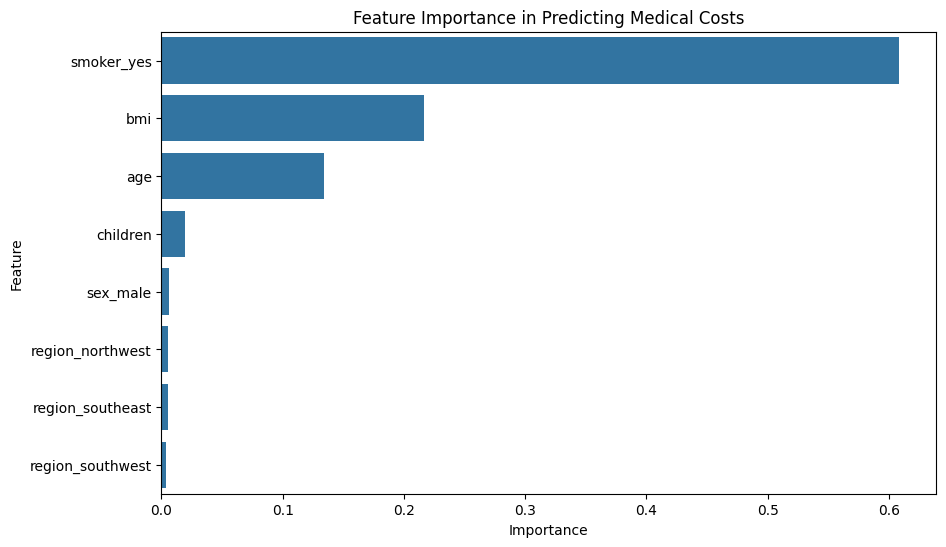

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance in Predicting Medical Costs')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [29]:
# Create data for a new person
new_person = pd.DataFrame({
    'age': [35],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [True],
    'smoker_yes': [False],
    'region_northwest': [False],
    'region_southeast': [True],
    'region_southwest': [False]
})

# Make sure the columns are in the same order as the training data
new_person = new_person[X.columns]

# Predict the medical insurance charge
prediction = gb_model.predict(new_person)

print(f"Predicted medical insurance charge: ${prediction[0]:,.2f}")

Predicted medical insurance charge: $7,436.35


In [30]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values[:10],
    'Predicted Charges': y_pred_gb[:10]
})

comparison

,Actual Charges,Predicted Charges
0,9095.06825,10825.369522
1,5272.17580,5794.881352
2,29330.98315,27836.174124
3,9301.89355,10011.452146
4,33750.29180,33446.034083
5,4536.25900,5410.894701
6,2117.33885,3522.884922
7,14210.53595,16800.836409
8,3732.62510,4661.392909
9,10264.44210,10985.281470


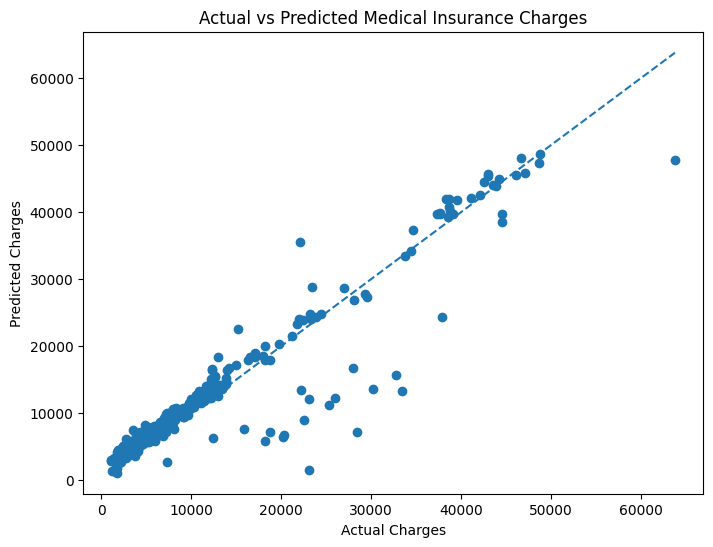

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_gb)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Insurance Charges')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [32]:
print("Final Model Performance")
print("=======================")
print(f"MAE  : {mae_gb:.2f}")
print(f"RMSE : {rmse_gb:.2f}")
print(f"R²   : {r2_gb:.4f}")

Final Model Performance
MAE  : 2443.48
RMSE : 4329.57
R²   : 0.8793


In [33]:
best_model = results.loc[results['R² Score'].idxmax()]

print("Best Model:", best_model['Model'])
print("R² Score:", best_model['R² Score'])

Best Model: Gradient Boosting
R² Score: 0.8792571359795264


In [34]:
results

,Model,MAE,RMSE,R² Score
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Random Forest,2550.078471,4576.299916,0.865103
2,Gradient Boosting,2443.483262,4329.570011,0.879257


In [35]:
best_model

Model       Gradient Boosting
MAE               2443.483262
RMSE              4329.570011
R² Score             0.879257
Name: 2, dtype: object

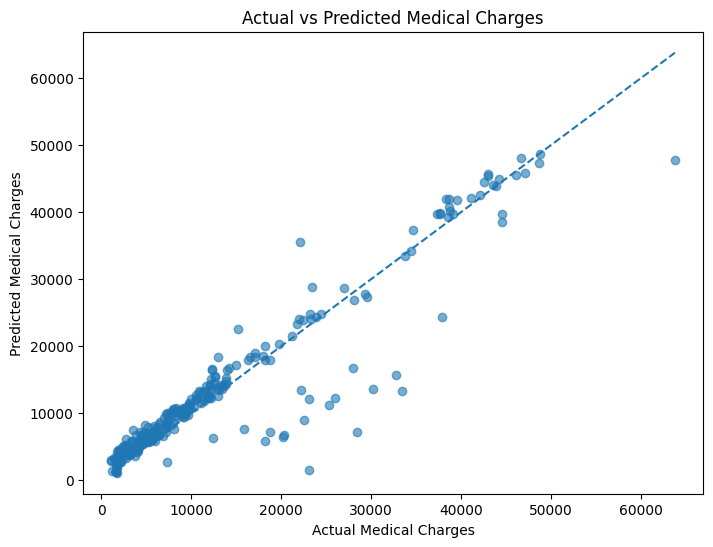

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_gb, alpha=0.6)

plt.xlabel('Actual Medical Charges')
plt.ylabel('Predicted Medical Charges')
plt.title('Actual vs Predicted Medical Charges')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
4        smoker_yes    0.676618
1               bmi    0.190540
0               age    0.118372
2          children    0.010212
5  region_northwest    0.001726
7  region_southwest    0.001378
3          sex_male    0.000627
6  region_southeast    0.000526


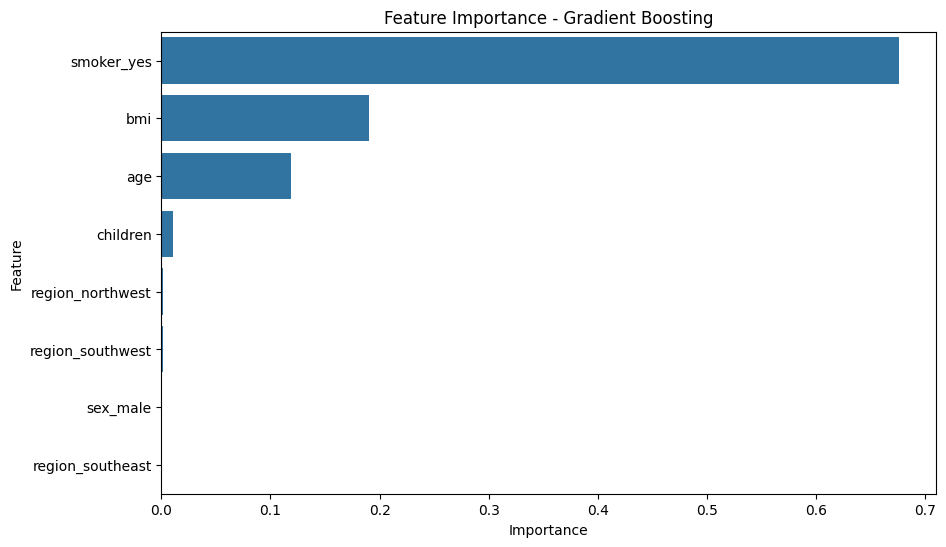

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [39]:
# Feature importance from the best model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker_yes,0.676618
1,bmi,0.190540
0,age,0.118372
2,children,0.010212
5,region_northwest,0.001726
7,region_southwest,0.001378
3,sex_male,0.000627
6,region_southeast,0.000526


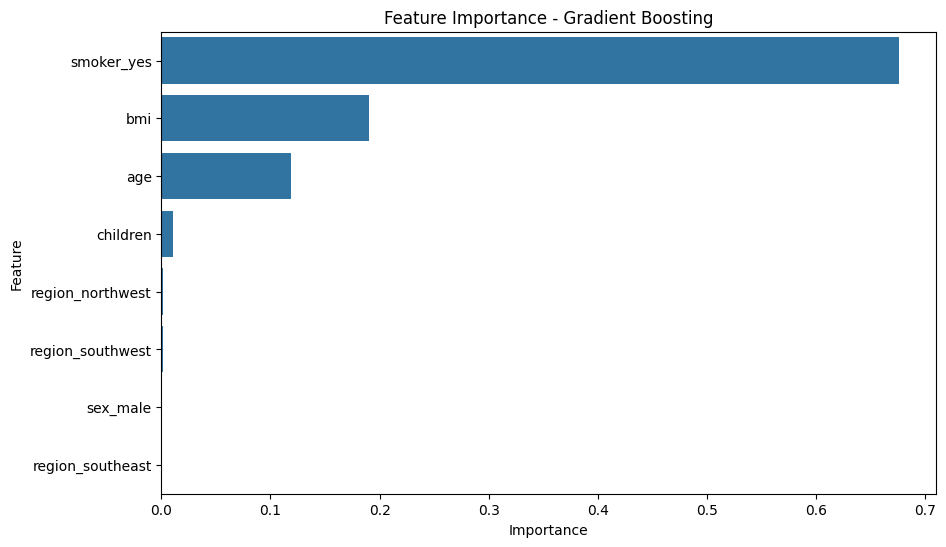

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [41]:
import joblib

joblib.dump(gb_model, 'gradient_boosting_insurance_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [42]:
print("FINAL MODEL")
print("-----------")
print("Model: Gradient Boosting")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

FINAL MODEL
-----------
Model: Gradient Boosting
MAE: 2443.48
RMSE: 4329.57
R² Score: 0.8793


## Conclusion

In this project, I used the Medical Cost Personal Dataset to explore the factors that influence individual medical insurance charges. I first examined and visualized the data before preparing the categorical variables for machine learning.

I compared three different regression models: Linear Regression, Random Forest, and Gradient Boosting. Linear Regression achieved an R² score of 0.7836, while Random Forest improved the performance to 0.8651. Gradient Boosting performed the best, with an R² score of **0.8793**, an MAE of **2,443.48**, and an RMSE of **4,329.57**.

The results show that machine learning can be useful for predicting medical insurance costs. The feature-importance analysis also helped identify the variables that contributed most to the predictions.

Overall, Gradient Boosting was the most suitable model among the three tested models because it produced the lowest prediction errors and the highest R² score. This demonstrates how data analysis and machine learning can be used to understand patterns in healthcare costs and make useful predictions.


## Key Findings

* Gradient Boosting was the best-performing model with an **R² score of 0.8793**.
* The model achieved an **MAE of 2,443.48**.
* The model achieved an **RMSE of 4,329.57**.
* Random Forest was the second-best model with an R² score of **0.8651**.
* Linear Regression had the lowest performance among the three models.
* Feature importance helped identify the variables that had the greatest influence on predicted medical insurance charges.
